BUSINESS OBJECTIVE

This notebook focuses on building an automatic ticket tagging system for ITSM operations.

The objective is to automatically predict the correct department or configuration category for incoming incidents.

Automated tagging helps:

- reduce ticket routing delays
- improve operational efficiency
- reduce reassignment counts
- support intelligent ITSM workflows

IMPORT LIBRARIES

In [22]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import joblib

LOAD CLEAN DATASET

In [23]:
df = pd.read_csv(
    r"C:\Projects_Dm\ITSM_project\data\processed\itsm_cleaned.csv",
    low_memory=False
)

print(df.shape)

df.head()

(45226, 26)


,CI_Name,CI_Cat,CI_Subcat,WBS,Incident_ID,Status,Impact,Urgency,Priority,number_cnt,...,Close_Time,Handle_Time_hrs,Closure_Code,No_of_Related_Interactions,Related_Interaction,Open_Year,Open_Month,Open_Day,Open_Hour,Open_Weekday
0,SUB000508,subapplication,Web Based Application,WBS000162,IM0000004,Closed,4,4,4.0,0.601292,...,2013-11-04 13:51:00,3.871691e+09,Other,1.0,SD0000007,2012,2,5,13,6
1,WBA000124,application,Web Based Application,WBS000088,IM0000005,Closed,3,3,3.0,0.415050,...,2013-12-02 12:36:00,4.354786e+09,Software,1.0,SD0000011,2012,3,12,15,0
2,WBA000124,application,Web Based Application,WBS000088,IM0000011,Closed,4,4,4.0,0.642927,...,2013-11-14 09:31:00,4.321833e+09,Operator error,1.0,SD0000025,2012,7,17,11,1
3,WBA000124,application,Web Based Application,WBS000088,IM0000012,Closed,4,4,4.0,0.345258,...,2013-11-08 13:55:00,3.383903e+09,Other,1.0,SD0000029,2012,8,10,11,4
4,WBA000124,application,Web Based Application,WBS000088,IM0000013,Closed,4,4,4.0,0.006676,...,2013-11-08 13:54:00,3.383437e+09,Other,1.0,SD0000031,2012,8,10,11,4


REMOVE UNNECESSARY COLUMNS

In [39]:
drop_cols = [

    'Incident_ID',

    'KB_number',

    'Related_Interaction',

    'WBS',

    'Open_Time',

    'Resolved_Time',

    'Close_Time',

    'CI_Name',

    'CI_Subcat'

]

TARGET VARIABLE

In [40]:
target_col = 'CI_Cat'

In [41]:
class_counts = df['CI_Cat'].value_counts()

valid_classes = class_counts[
    class_counts >= 20
].index

df = df[
    df['CI_Cat'].isin(valid_classes)
]

ENCODE TARGET

In [42]:
target_encoder = LabelEncoder()

df[target_col] = target_encoder.fit_transform(
    df[target_col].astype(str)
)

ENCODE FEATURES

In [43]:
label_encoders = {}

categorical_cols = df.select_dtypes(
    include=['object']
).columns

for col in categorical_cols:

    le = LabelEncoder()

    df[col] = le.fit_transform(
        df[col].astype(str)
    )

    label_encoders[col] = le

FEATURES & TARGET

In [44]:
X = df.drop(target_col, axis=1)

y = df[target_col]

TRAIN TEST SPLIT

In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

TRAIN MODELS

In [46]:
#RANDOM FOREST
rf_model = RandomForestClassifier(

    n_estimators=300,

    max_depth=20,

    min_samples_split=5,

    min_samples_leaf=2,

    class_weight='balanced',

    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [47]:
#XGBOOST
xgb_model = XGBClassifier(

    n_estimators=300,

    learning_rate=0.05,

    max_depth=8,

    subsample=0.8,

    colsample_bytree=0.8,

    eval_metric='mlogloss',

    random_state=42
)
xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

EVALUATION FUNCTION


In [48]:
def evaluate_model(model_name, y_test, y_pred):

    print(f"\n{'='*50}")

    print(model_name)

    print(f"{'='*50}")

    print("\nAccuracy Score:\n")

    print(
        accuracy_score(y_test, y_pred)
    )

    print("\nClassification Report:\n")

    print(
        classification_report(
            y_test,
            y_pred
        )
    )

In [49]:
evaluate_model(
    "Random Forest",
    y_test,
    rf_pred
)

evaluate_model(
    "XGBoost",
    y_test,
    xgb_pred
)


Random Forest

Accuracy Score:

0.9973463069438302

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6397
           1       1.00      0.99      0.99       709
           2       1.00      0.97      0.98        33
           3       0.98      1.00      0.99        42
           4       0.99      0.94      0.96        81
           5       0.94      0.85      0.89        20
           6       1.00      1.00      1.00        28
           7       1.00      0.95      0.97        59
           8       1.00      0.98      0.99       131
           9       1.00      1.00      1.00      1544

    accuracy                           1.00      9044
   macro avg       0.99      0.97      0.98      9044
weighted avg       1.00      1.00      1.00      9044


XGBoost

Accuracy Score:

0.9994471472799646

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00     

FEATURE IMPORTANCE

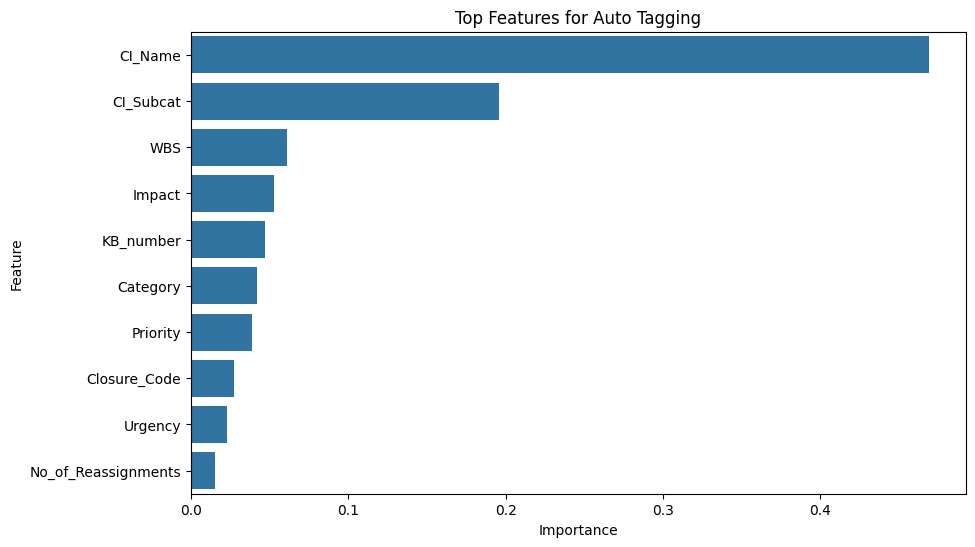

In [50]:
feature_importance = pd.DataFrame({

    'Feature': X.columns,

    'Importance': xgb_model.feature_importances_

})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance.head(10)
)

plt.title("Top Features for Auto Tagging")

plt.show()

SAVE MODEL

In [51]:
joblib.dump(
    xgb_model,
    r"C:\Projects_Dm\ITSM_project\models\auto_tagging_model.pkl"
)

print("Auto tagging model saved successfully")

Auto tagging model saved successfully


CROSS VALIDATION

In [54]:
from sklearn.model_selection import cross_val_score

In [59]:
cv_scores = cross_val_score(

    xgb_model,

    X,

    y,

    cv=5,

    scoring='accuracy'

)

print("Cross Validation Scores:\n")

print(cv_scores)

print("\nAverage CV Accuracy:\n")

print(cv_scores.mean())

Cross Validation Scores:

[0.99922601 0.99988943 0.99944715 0.99900487 0.99977886]

Average CV Accuracy:

0.9994692613887659


BUSINESS CONCLUSION

The auto-tagging model successfully predicts incident configuration categories using operational incident attributes.

This system can help:

- reduce ticket reassignment delays
- improve routing accuracy
- support intelligent ITSM automation
- improve operational efficiency